<a href="https://colab.research.google.com/github/Maria-SSN/Shrodinger/blob/main/Pr%C3%A0ctica%202_modificaci%C3%B3%20de%20c%C3%A0lcula%20MC_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MonteCarl (MC) simulation of a system of Lennard-Jones Spheres**

Simulation of a system of N atoms in a box of fixed dimensions (so fixed density) at a specified temeprature T.

Units: distance in Å and energy in kcal/mol

The Montecarlo  Metropolis simuation produces:
- A file with the positions of the atoms generated at the different MC steps
- The Energy along the simulation
- The number of accepted and rejected MC jumps


In [1]:
# Import libraries
import random
import math
import copy
import matplotlib.pyplot as plt

**Physical parameters of the simulation (25 atoms)**

In [2]:
# Set the number of atoms in the box
n_atoms = 25

# Set the number of Monte Carlo moves to perform
num_moves = 5000

# Set the size of the box (in Angstroms)
box_size = [ 15.0, 15.0, 15.0 ]

# The maximum amount that the atom can be translated by
max_translate = 0.5    # angstroms

# Simulation temperature
temperature = 298.15   # kelvin

# Give the Lennard Jones parameters for the atoms
# (these are the OPLS parameters for Krypton)
sigma = 3.624         # angstroms
epsilon = 0.317       # kcal mol-1

**Simulation code**
Create data files and initial coordinates

In [3]:
# Create a data file to output coordinates
filename="trajectory.pdb"
FILE = open(filename, "w")
# Create a data file to output Energy and other data
FILE2= open("Energy.dat","w")

# Create an array to hold the coordinates of the atoms
coords = []

# Randomly generate the coordinates of the atoms in the box
for i in range(0,n_atoms):
    # Note "random.uniform(x,y)" would generate a random number
    # between x and y
    coords.append( [random.uniform(0,box_size[0]), \
                    random.uniform(0,box_size[1]), \
                    random.uniform(0,box_size[2]) ] )

Functions for the simulation

In [4]:
def make_periodic(x, box):
    """Subroutine to apply periodic boundaries"""
    while (x < -0.5*box):
        x += box

    while (x > 0.5*box):
        x -= box

    return x


def wrap_into_box(x, box):
    """Subroutine to wrap the coordinates into a box"""
    while (x > box):
        x -= box

    while (x < 0):
        x += box

    return x


def print_pdb(move):
	#Open file to add data
    FILE = open(filename, "a")

    #write simulation box data
    FILE.write("CRYST1 %8.3f %8.3f %8.3f  90.00  90.00  90.00\n" % \
                  (box_size[0], box_size[1], box_size[2]))

    #write atoms data
    for i in range(0,n_atoms):
        FILE.write("ATOM  %5d  Kr   Kr     1    %8.3f%8.3f%8.3f  1.00  0.00          Kr\n" % \
                      (i+1, coords[i][0], coords[i][1], coords[i][2]))
        #FILE.write("TER\n")

    #close file
    FILE.write("END\n")
    FILE.close()


# Subroutine that calculates the energies of the atoms
def calculate_energy():
    """Calculate the energy of the passed atoms (assuming all atoms
       have the same LJ sigma and epsilon values)"""

    # Loop over all pairs of atoms and calculate
    # the LJ energy
    total_energy = 0

    for i in range(0,n_atoms-1):
        for j in range(i+1, n_atoms):
            delta_x = coords[j][0] - coords[i][0]
            delta_y = coords[j][1] - coords[i][1]
            delta_z = coords[j][2] - coords[i][2]

            # Apply periodic boundaries
            delta_x = make_periodic(delta_x, box_size[0])
            delta_y = make_periodic(delta_y, box_size[1])
            delta_z = make_periodic(delta_z, box_size[2])

            # Calculate the distance between the atoms
            r = math.sqrt( (delta_x*delta_x) + (delta_y*delta_y) +
                           (delta_z*delta_z) )

            # E_LJ = 4*epsilon[ (sigma/r)^12 - (sigma/r)^6 ]
            e_lj = 4.0 * epsilon * ( (sigma/r)**12 - (sigma/r)**6 )

            total_energy += e_lj

    # return the total energy of the atoms
    return total_energy


**Main program for the calculation**

10 59398.74518463124  4  6
20 58712.60191542337  7  13
30 58374.700194951656  11  19
40 58337.4520420717  16  24
50 52084.12791475187  26  24
60 51981.48576784358  29  31
70 43157.28682291345  37  33
80 11080.685689074226  44  36
90 3114.1884218968025  50  40
100 3087.813857255685  55  45
110 2804.973134144567  60  50
120 2752.3617501636472  67  53
130 2187.191417605722  72  58
140 1132.8710031094224  79  61
150 718.2238626032156  83  67
160 415.19298337932236  89  71
170 412.4938206466613  92  78
180 409.7844915930561  98  82
190 312.08424739856133  103  87
200 197.3416512809211  109  91
210 169.65950105987432  113  97
220 165.95971022100758  120  100
230 169.21978399665437  125  105
240 112.16040916196049  129  111
250 106.7540971702238  133  117
260 104.10201771400575  138  122
270 101.56434625744873  143  127
280 71.8874472866542  150  130
290 58.36391991422939  154  136
300 16.120884132203415  162  138
310 15.571704941950548  165  145
320 16.4656858964521  170  150
330 15.97769154

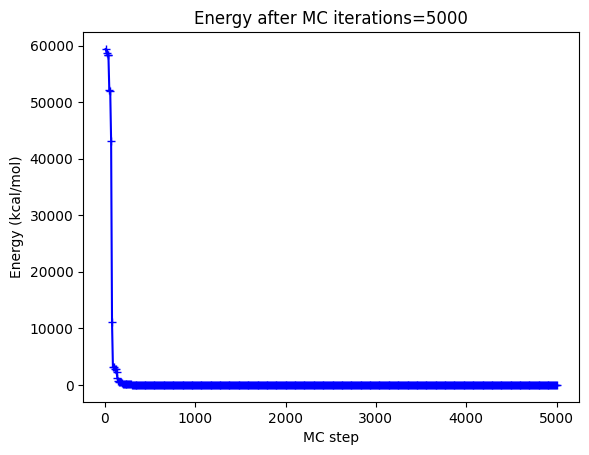

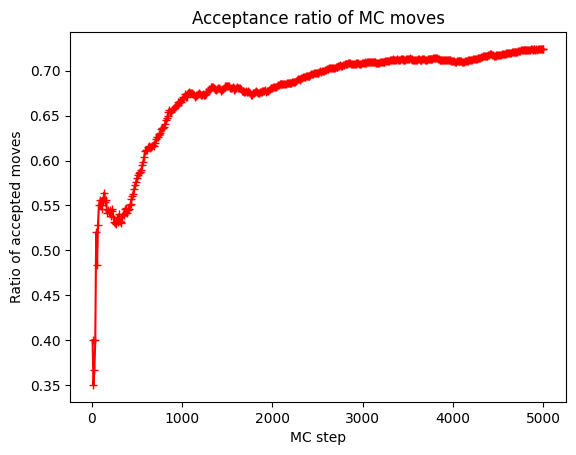

In [5]:
# calculate kT
k_boltz = 1.987206504191549E-003  # kcal mol-1 K-1

kT = k_boltz * temperature

# The total number of accepted moves
naccept = 0

# The total number of rejected moves
nreject = 0

#ratio accepted/total
ratio=[]

# Potential Energy
Epot_t=[]
t_step=[]

# Save the initial coordinates in PDB file
print_pdb(0)

# Now perform all of the moves
for move in range(1,num_moves+1):

    # calculate the old energy
    old_energy = calculate_energy()

    # Pick a random atom (random.randint(x,y) picks a random
    # integer between x and y, including x and y)
    atom = random.randint(0, n_atoms-1)

    # save the old coordinates
    old_coords = copy.deepcopy(coords)

    # Make the move - translate by a delta in each dimension
    delta_x = random.uniform( -max_translate, max_translate )
    delta_y = random.uniform( -max_translate, max_translate )
    delta_z = random.uniform( -max_translate, max_translate )

    coords[atom][0] += delta_x
    coords[atom][1] += delta_y
    coords[atom][2] += delta_z

    # wrap the coordinates back into the box
    coords[atom][0] = wrap_into_box(coords[atom][0], box_size[0])
    coords[atom][1] = wrap_into_box(coords[atom][1], box_size[1])
    coords[atom][2] = wrap_into_box(coords[atom][2], box_size[2])

    # calculate the new energy
    new_energy = calculate_energy()

    accept = False

    # Automatically accept if the energy goes down
    if (new_energy <= old_energy):
        accept = True

    else:
        # Now apply the Monte Carlo test - compare
        # exp( -(E_new - E_old) / kT ) >= rand(0,1)
        x = math.exp( -(new_energy - old_energy) / kT )

        if (x >= random.uniform(0.0,1.0)):
            accept = True
        else:
            accept = False

    if accept:
        # accept the move
        naccept += 1
        total_energy = new_energy
    else:
        # reject the move - restore the old coordinates
        nreject += 1

        # restore the old conformation
        coords = copy.deepcopy(old_coords)

        total_energy = old_energy

    # print the energy every 10 moves
    if move % 10 == 0:
        print("%s %s  %s  %s" % (move, total_energy, naccept, nreject))
        FILE2.write("%s %s  %s  %s \n" % (move, total_energy, naccept, nreject))

        #accumulate data
        ratio.append(float(naccept)/float(naccept+nreject))
        Epot_t.append(total_energy)
        t_step.append(move)

    # print the coordinates every 100 moves
    if move % 100 == 0:
        print_pdb(move)

#End of calculation
FILE2.close()
#interactive plotting off
#Plot evolution of Energy
plt.title('Energy after MC iterations=%d'%move);
plt.ylabel('Energy (kcal/mol)')
plt.plot(t_step, Epot_t, 'b+-')
plt.xlabel('MC step')
plt.show()

#Plot evolution of accepted/rejected trials
plt.title('Acceptance ratio of MC moves');
plt.ylabel('Ratio of accepted moves')
plt.xlabel('MC step')
plt.plot(t_step, ratio, 'r+-')
plt.show()

**Simulació amb 100 atoms**

In [7]:
# Set the number of atoms in the box
n_atoms = 100

# Set the number of Monte Carlo moves to perform
num_moves = 5000

# Set the size of the box (in Angstroms)
box_size = [ 15.0, 15.0, 15.0 ]

# The maximum amount that the atom can be translated by
max_translate = 0.5    # angstroms

# Simulation temperature
temperature = 298.15   # kelvin

# Give the Lennard Jones parameters for the atoms
# (these are the OPLS parameters for Krypton)
sigma = 3.624         # angstroms
epsilon = 0.317       # kcal mol-1

In [8]:
# Create a data file to output coordinates
filename="trajectory.pdb"
FILE = open(filename, "w")
# Create a data file to output Energy and other data
FILE2= open("Energy.dat","w")

# Create an array to hold the coordinates of the atoms
coords = []

# Randomly generate the coordinates of the atoms in the box
for i in range(0,n_atoms):
    # Note "random.uniform(x,y)" would generate a random number
    # between x and y
    coords.append( [random.uniform(0,box_size[0]), \
                    random.uniform(0,box_size[1]), \
                    random.uniform(0,box_size[2]) ] )

In [9]:
def make_periodic(x, box):
    """Subroutine to apply periodic boundaries"""
    while (x < -0.5*box):
        x += box

    while (x > 0.5*box):
        x -= box

    return x


def wrap_into_box(x, box):
    """Subroutine to wrap the coordinates into a box"""
    while (x > box):
        x -= box

    while (x < 0):
        x += box

    return x


def print_pdb(move):
	#Open file to add data
    FILE = open(filename, "a")

    #write simulation box data
    FILE.write("CRYST1 %8.3f %8.3f %8.3f  90.00  90.00  90.00\n" % \
                  (box_size[0], box_size[1], box_size[2]))

    #write atoms data
    for i in range(0,n_atoms):
        FILE.write("ATOM  %5d  Kr   Kr     1    %8.3f%8.3f%8.3f  1.00  0.00          Kr\n" % \
                      (i+1, coords[i][0], coords[i][1], coords[i][2]))
        #FILE.write("TER\n")

    #close file
    FILE.write("END\n")
    FILE.close()


# Subroutine that calculates the energies of the atoms
def calculate_energy():
    """Calculate the energy of the passed atoms (assuming all atoms
       have the same LJ sigma and epsilon values)"""

    # Loop over all pairs of atoms and calculate
    # the LJ energy
    total_energy = 0

    for i in range(0,n_atoms-1):
        for j in range(i+1, n_atoms):
            delta_x = coords[j][0] - coords[i][0]
            delta_y = coords[j][1] - coords[i][1]
            delta_z = coords[j][2] - coords[i][2]

            # Apply periodic boundaries
            delta_x = make_periodic(delta_x, box_size[0])
            delta_y = make_periodic(delta_y, box_size[1])
            delta_z = make_periodic(delta_z, box_size[2])

            # Calculate the distance between the atoms
            r = math.sqrt( (delta_x*delta_x) + (delta_y*delta_y) +
                           (delta_z*delta_z) )

            # E_LJ = 4*epsilon[ (sigma/r)^12 - (sigma/r)^6 ]
            e_lj = 4.0 * epsilon * ( (sigma/r)**12 - (sigma/r)**6 )

            total_energy += e_lj

    # return the total energy of the atoms
    return total_energy


10 10612508606491.281  6  4
20 10612456812074.492  10  10
30 430167362757.2846  17  13
40 370533279675.36456  22  18
50 370531243041.43054  25  25
60 370531218605.22815  30  30
70 370531214487.6027  36  34
80 370530331600.6609  40  40
90 111065886301.35522  48  42
100 111038905432.16058  54  46
110 111033994004.03691  58  52
120 111033830084.88985  62  58
130 111030131942.93076  67  63
140 111030012894.59161  72  68
150 195173703.85685265  76  74
160 195121410.46127212  80  80
170 195106989.74133384  86  84
180 195106989.74133384  86  94
190 194806523.24251875  89  101
200 194237371.5304768  93  107
210 86937881.52951133  98  112
220 86454270.8155358  104  116
230 86429655.85986891  107  123
240 86423545.79287693  110  130
250 85232231.15887539  117  133
260 84484800.00269285  122  138
270 84378083.52363698  129  141
280 83225771.50005673  134  146
290 3779550.939004801  139  151
300 3277449.033202664  143  157
310 3274422.0028926935  147  163
320 3274357.67934199  150  170
330 3018141

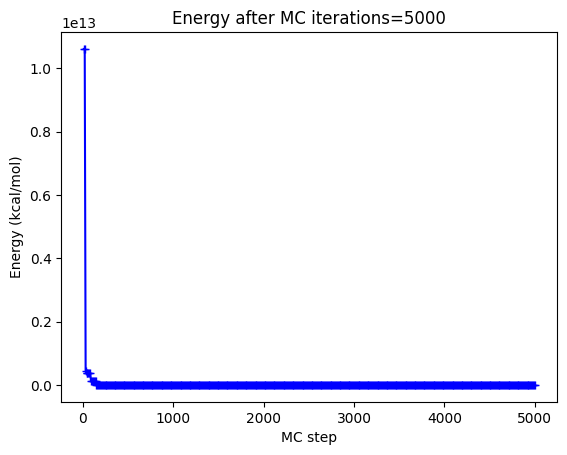

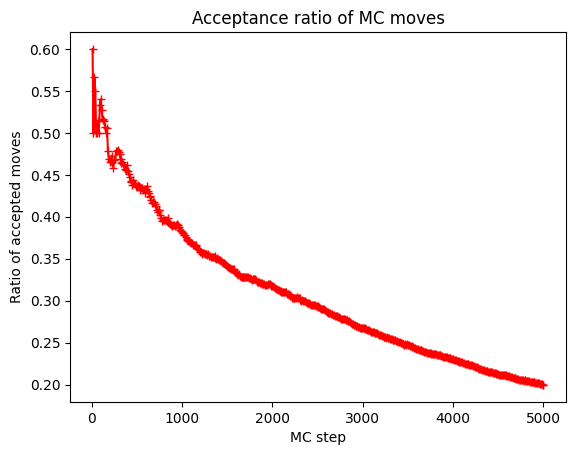

In [10]:
# calculate kT
k_boltz = 1.987206504191549E-003  # kcal mol-1 K-1

kT = k_boltz * temperature

# The total number of accepted moves
naccept = 0

# The total number of rejected moves
nreject = 0

#ratio accepted/total
ratio=[]

# Potential Energy
Epot_t=[]
t_step=[]

# Save the initial coordinates in PDB file
print_pdb(0)

# Now perform all of the moves
for move in range(1,num_moves+1):

    # calculate the old energy
    old_energy = calculate_energy()

    # Pick a random atom (random.randint(x,y) picks a random
    # integer between x and y, including x and y)
    atom = random.randint(0, n_atoms-1)

    # save the old coordinates
    old_coords = copy.deepcopy(coords)

    # Make the move - translate by a delta in each dimension
    delta_x = random.uniform( -max_translate, max_translate )
    delta_y = random.uniform( -max_translate, max_translate )
    delta_z = random.uniform( -max_translate, max_translate )

    coords[atom][0] += delta_x
    coords[atom][1] += delta_y
    coords[atom][2] += delta_z

    # wrap the coordinates back into the box
    coords[atom][0] = wrap_into_box(coords[atom][0], box_size[0])
    coords[atom][1] = wrap_into_box(coords[atom][1], box_size[1])
    coords[atom][2] = wrap_into_box(coords[atom][2], box_size[2])

    # calculate the new energy
    new_energy = calculate_energy()

    accept = False

    # Automatically accept if the energy goes down
    if (new_energy <= old_energy):
        accept = True

    else:
        # Now apply the Monte Carlo test - compare
        # exp( -(E_new - E_old) / kT ) >= rand(0,1)
        x = math.exp( -(new_energy - old_energy) / kT )

        if (x >= random.uniform(0.0,1.0)):
            accept = True
        else:
            accept = False

    if accept:
        # accept the move
        naccept += 1
        total_energy = new_energy
    else:
        # reject the move - restore the old coordinates
        nreject += 1

        # restore the old conformation
        coords = copy.deepcopy(old_coords)

        total_energy = old_energy

    # print the energy every 10 moves
    if move % 10 == 0:
        print("%s %s  %s  %s" % (move, total_energy, naccept, nreject))
        FILE2.write("%s %s  %s  %s \n" % (move, total_energy, naccept, nreject))

        #accumulate data
        ratio.append(float(naccept)/float(naccept+nreject))
        Epot_t.append(total_energy)
        t_step.append(move)

    # print the coordinates every 100 moves
    if move % 100 == 0:
        print_pdb(move)

#End of calculation
FILE2.close()
#interactive plotting off
#Plot evolution of Energy
plt.title('Energy after MC iterations=%d'%move);
plt.ylabel('Energy (kcal/mol)')
plt.plot(t_step, Epot_t, 'b+-')
plt.xlabel('MC step')
plt.show()

#Plot evolution of accepted/rejected trials
plt.title('Acceptance ratio of MC moves');
plt.ylabel('Ratio of accepted moves')
plt.xlabel('MC step')
plt.plot(t_step, ratio, 'r+-')
plt.show()

**Simulació amb 10 atoms**

In [34]:
# Import libraries
import random
import math
import copy
import matplotlib.pyplot as plt

In [35]:
# Set the number of atoms in the box
n_atoms = 500

# Set the number of Monte Carlo moves to perform
num_moves = 5000

# Set the size of the box (in Angstroms)
box_size = [ 15.0, 15.0, 15.0 ]

# The maximum amount that the atom can be translated by
max_translate = 0.5    # angstroms

# Simulation temperature
temperature = 298.15   # kelvin

# Give the Lennard Jones parameters for the atoms
# (these are the OPLS parameters for Krypton)
sigma = 3.624         # angstroms
epsilon = 0.317       # kcal mol-1

In [36]:
# Create a data file to output coordinates
filename="trajectory.pdb"
FILE = open(filename, "w")
# Create a data file to output Energy and other data
FILE2= open("Energy.dat","w")

# Create an array to hold the coordinates of the atoms
coords = []

# Randomly generate the coordinates of the atoms in the box
for i in range(0,n_atoms):
    # Note "random.uniform(x,y)" would generate a random number
    # between x and y
    coords.append( [random.uniform(0,box_size[0]), \
                    random.uniform(0,box_size[1]), \
                    random.uniform(0,box_size[2]) ] )

In [37]:
def make_periodic(x, box):
    """Subroutine to apply periodic boundaries"""
    while (x < -0.5*box):
        x += box

    while (x > 0.5*box):
        x -= box

    return x


def wrap_into_box(x, box):
    """Subroutine to wrap the coordinates into a box"""
    while (x > box):
        x -= box

    while (x < 0):
        x += box

    return x


def print_pdb(move):
	#Open file to add data
    FILE = open(filename, "a")

    #write simulation box data
    FILE.write("CRYST1 %8.3f %8.3f %8.3f  90.00  90.00  90.00\n" % \
                  (box_size[0], box_size[1], box_size[2]))

    #write atoms data
    for i in range(0,n_atoms):
        FILE.write("ATOM  %5d  Kr   Kr     1    %8.3f%8.3f%8.3f  1.00  0.00          Kr\n" % \
                      (i+1, coords[i][0], coords[i][1], coords[i][2]))
        #FILE.write("TER\n")

    #close file
    FILE.write("END\n")
    FILE.close()


# Subroutine that calculates the energies of the atoms
def calculate_energy():
    """Calculate the energy of the passed atoms (assuming all atoms
       have the same LJ sigma and epsilon values)"""

    # Loop over all pairs of atoms and calculate
    # the LJ energy
    total_energy = 0

    for i in range(0,n_atoms-1):
        for j in range(i+1, n_atoms):
            delta_x = coords[j][0] - coords[i][0]
            delta_y = coords[j][1] - coords[i][1]
            delta_z = coords[j][2] - coords[i][2]

            # Apply periodic boundaries
            delta_x = make_periodic(delta_x, box_size[0])
            delta_y = make_periodic(delta_y, box_size[1])
            delta_z = make_periodic(delta_z, box_size[2])

            # Calculate the distance between the atoms
            r = math.sqrt( (delta_x*delta_x) + (delta_y*delta_y) +
                           (delta_z*delta_z) )

            # E_LJ = 4*epsilon[ (sigma/r)^12 - (sigma/r)^6 ]
            e_lj = 4.0 * epsilon * ( (sigma/r)**12 - (sigma/r)**6 )

            total_energy += e_lj

    # return the total energy of the atoms
    return total_energy


100 256775752234037.7  36  64
200 253423459649032.25  82  118
300 253255683388132.53  134  166
400 251564422136931.7  175  225
500 144068596052650.72  227  273
600 143078145843616.94  260  340
700 551405181043.7183  301  399
800 526459550887.14087  337  463
900 485878014561.27527  382  518
1000 427347624878.55444  429  571
1100 415530822219.04095  474  626
1200 52024177301.12771  519  681
1300 12268815528.018335  554  746
1400 11820745148.15155  595  805
1500 11396438586.382357  633  867
1600 10580250958.543922  669  931
1700 10294102834.076656  704  996
1800 10283632368.434652  732  1068
1900 9268436620.56551  762  1138
2000 8814097954.10681  793  1207
2100 2975434494.628795  824  1276
2200 2694962116.16334  856  1344
2300 2668278437.5912795  887  1413
2400 2413473010.9612055  920  1480
2500 2378975374.7780833  949  1551
2600 2368081177.2902474  980  1620
2700 2261067273.8248787  1004  1696
2800 185207180.35107595  1026  1774
2900 183635477.90895352  1045  1855
3000 179213228.73000532

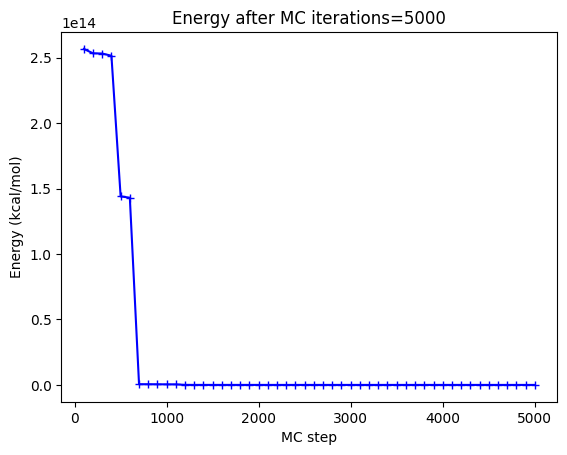

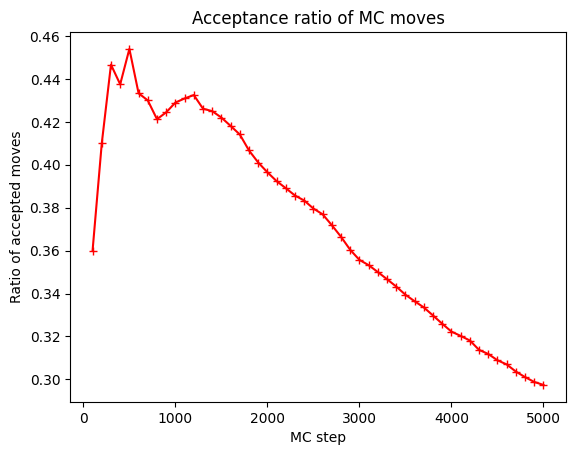

In [38]:
# calculate kT
k_boltz = 1.987206504191549E-003  # kcal mol-1 K-1

kT = k_boltz * temperature

# The total number of accepted moves
naccept = 0

# The total number of rejected moves
nreject = 0

#ratio accepted/total
ratio=[]

# Potential Energy
Epot_t=[]
t_step=[]

# Save the initial coordinates in PDB file
print_pdb(0)

# Now perform all of the moves
for move in range(1,num_moves+1):

    # calculate the old energy
    old_energy = calculate_energy()

    # Pick a random atom (random.randint(x,y) picks a random
    # integer between x and y, including x and y)
    atom = random.randint(0, n_atoms-1)

    # save the old coordinates
    old_coords = copy.deepcopy(coords)

    # Make the move - translate by a delta in each dimension
    delta_x = random.uniform( -max_translate, max_translate )
    delta_y = random.uniform( -max_translate, max_translate )
    delta_z = random.uniform( -max_translate, max_translate )

    coords[atom][0] += delta_x
    coords[atom][1] += delta_y
    coords[atom][2] += delta_z

    # wrap the coordinates back into the box
    coords[atom][0] = wrap_into_box(coords[atom][0], box_size[0])
    coords[atom][1] = wrap_into_box(coords[atom][1], box_size[1])
    coords[atom][2] = wrap_into_box(coords[atom][2], box_size[2])

    # calculate the new energy
    new_energy = calculate_energy()

    accept = False

    # Automatically accept if the energy goes down
    if (new_energy <= old_energy):
        accept = True

    else:
        # Now apply the Monte Carlo test - compare
        # exp( -(E_new - E_old) / kT ) >= rand(0,1)
        x = math.exp( -(new_energy - old_energy) / kT )

        if (x >= random.uniform(0.0,1.0)):
            accept = True
        else:
            accept = False

    if accept:
        # accept the move
        naccept += 1
        total_energy = new_energy
    else:
        # reject the move - restore the old coordinates
        nreject += 1

        # restore the old conformation
        coords = copy.deepcopy(old_coords)

        total_energy = old_energy

    # print the energy every 10 moves
    if move % 100 == 0:
        print("%s %s  %s  %s" % (move, total_energy, naccept, nreject))
        FILE2.write("%s %s  %s  %s \n" % (move, total_energy, naccept, nreject))

        #accumulate data
        ratio.append(float(naccept)/float(naccept+nreject))
        Epot_t.append(total_energy)
        t_step.append(move)

    # print the coordinates every 100 moves
    if move % 10 == 0:
        print_pdb(move)

#End of calculation
FILE2.close()
#interactive plotting off
#Plot evolution of Energy
plt.title('Energy after MC iterations=%d'%move);
plt.ylabel('Energy (kcal/mol)')
plt.plot(t_step, Epot_t, 'b+-')
plt.xlabel('MC step')
plt.show()

#Plot evolution of accepted/rejected trials
plt.title('Acceptance ratio of MC moves');
plt.ylabel('Ratio of accepted moves')
plt.xlabel('MC step')
plt.plot(t_step, ratio, 'r+-')
plt.show()